# LSL Test Demo

在 VS Code Jupyter 中使用 `lsl_test/` 下的模块进行 EEG 数据分析。

## 1. 环境准备

In [3]:
import sys
from pathlib import Path

# 健壮地定位项目根目录（repo 根目录应包含 thymio_control/ 目录）
project_root = Path.cwd()
if not (project_root / "thymio_control").exists():
    project_root = project_root.parent
if not (project_root / "thymio_control").exists():
    raise RuntimeError("无法找到项目根目录（应包含 thymio_control/ 目录）")

# thymio_control 包位于 project_root/thymio_control/thymio_control/
# 需要把 project_root/thymio_control/ 加入 sys.path 才能 import thymio_control.xxx
for p in [project_root, project_root / "thymio_control"]:
    s = str(p)
    if s not in sys.path:
        sys.path.insert(0, s)

import numpy as np
import matplotlib.pyplot as plt
print(f"project_root = {project_root}")


project_root = /Users/z31wang/Documents/MIASHS/M2/insei/ros_thymio


## 2. 读取 EDF 文件

In [4]:
from lsl_test.edf_reader import EdfReader

edf_path = project_root / 'enobio_recodes' / '20260408111446_Patient01.edf'
reader = EdfReader(edf_path)

meta = reader.metadata
print(f"患者ID: {meta.patient_id}")
print(f"记录时间: {meta.start_datetime}")
print(f"信号数量: {len(meta.signals)}")
print(f"数据记录数: {meta.n_data_records}")
print(f"记录时长: {meta.record_duration_sec} 秒")

for i, sig in enumerate(meta.signals):
    if sig.label in ('F3', 'F4', 'Fz'):
        print(f"  ch{i}: {sig.label} ({sig.sample_rate} Hz, {sig.physical_dim})")

meta


患者ID: 
记录时间: 2026-4-8 11:14:46
信号数量: 23
数据记录数: 539
记录时长: 1.0 秒
  ch11: F4 (500 Hz, nV)
  ch13: Fz (500 Hz, nV)
  ch15: F3 (500 Hz, nV)


EdfRecordingMetadata(patient_id='', recording_id='', start_datetime='2026-4-8 11:14:46', signals=[EdfSignalMetadata(label='P7', physical_dim='nV', physical_min=-1.0, physical_max=0.0, digital_min=-32768, digital_max=32767, sample_rate=500), EdfSignalMetadata(label='P4', physical_dim='nV', physical_min=-32770000.000000004, physical_max=1384124.0, digital_min=-32768, digital_max=32767, sample_rate=500), EdfSignalMetadata(label='Cz', physical_dim='nV', physical_min=-32770000.000000004, physical_max=1966135.0, digital_min=-32768, digital_max=32767, sample_rate=500), EdfSignalMetadata(label='Pz', physical_dim='nV', physical_min=-32770000.000000004, physical_max=7338495.0, digital_min=-32768, digital_max=32767, sample_rate=500), EdfSignalMetadata(label='P3', physical_dim='nV', physical_min=-6948519.0, physical_max=32768000.0, digital_min=-32768, digital_max=32767, sample_rate=500), EdfSignalMetadata(label='P8', physical_dim='nV', physical_min=-1892588.0, physical_max=461519.0, digital_min=-3

## 3. 读取信号并可视化

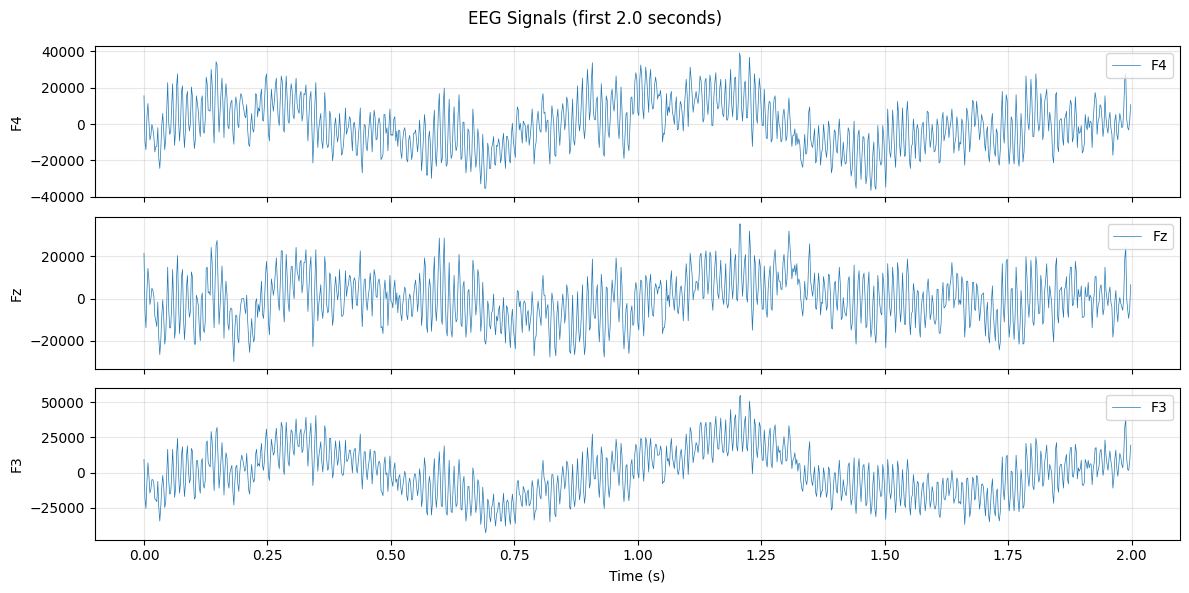

In [5]:
# 读取前3个EEG通道
eeg_indices = [i for i, s in enumerate(meta.signals) if s.label in ('F3', 'F4', 'Fz')]
signals = reader.read_signals(eeg_indices)
labels = [meta.signals[i].label for i in eeg_indices]

# 取前1000个样本可视化
sample_rate = int(meta.signals[eeg_indices[0]].sample_rate)
n_show = 1000
t = np.arange(n_show) / sample_rate

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.plot(t, signals[i, :n_show], label=label, linewidth=0.5)
    ax.set_ylabel(label)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (s)')
plt.suptitle(f'EEG Signals (first {n_show/sample_rate:.1f} seconds)')
plt.tight_layout()
plt.show()

## 4. 计算频段功率

使用 Welch 方法估算功率谱密度。`compute_band_powers` 默认使用 1 秒窗口、256 点 FFT 分段，
传入整段信号时会自动取前 `window_sec * sample_rate` 个样本。

In [6]:
from lsl_test.eeg_processor import compute_band_powers, band_power_to_metrics

# 对第 2 个通道（F4）计算频段功率
ch1 = signals[1]
bp = compute_band_powers(ch1, sample_rate=sample_rate)

print("频段功率 (nV^2):")
print(f"  delta (1-4 Hz):  {bp.delta:.2f}")
print(f"  theta (4-8 Hz):  {bp.theta:.2f}")
print(f"  alpha (8-13 Hz): {bp.alpha:.2f}")
print(f"  beta  (13-30 Hz): {bp.beta:.2f}")
print(f"  gamma (30-100 Hz): {bp.gamma:.2f}")

# 转换为 metrics（与 EegFrame 兼容的字典格式）
metrics = band_power_to_metrics(bp)
print("\nMetrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

频段功率 (nV^2):
  delta (1-4 Hz):  159241520.03
  theta (4-8 Hz):  112894965.50
  alpha (8-13 Hz): 107538597.98
  beta  (13-30 Hz): 452902560.08
  gamma (30-100 Hz): 2654589600.26

Metrics:
  alpha: 107538597.9777
  beta: 452902560.0809
  theta: 112894965.4989
  delta: 159241520.0302
  gamma: 2654589600.2624
  theta_beta: 0.2493
  alpha_beta: 0.2374


## 5. 每个通道的完整五频段功率

这里不再按脑区做特殊分组，而是直接对每个通道计算完整的 delta / theta / alpha / beta / gamma 五个频段功率。
这样更适合做通道级比较，也更不容易丢信息。


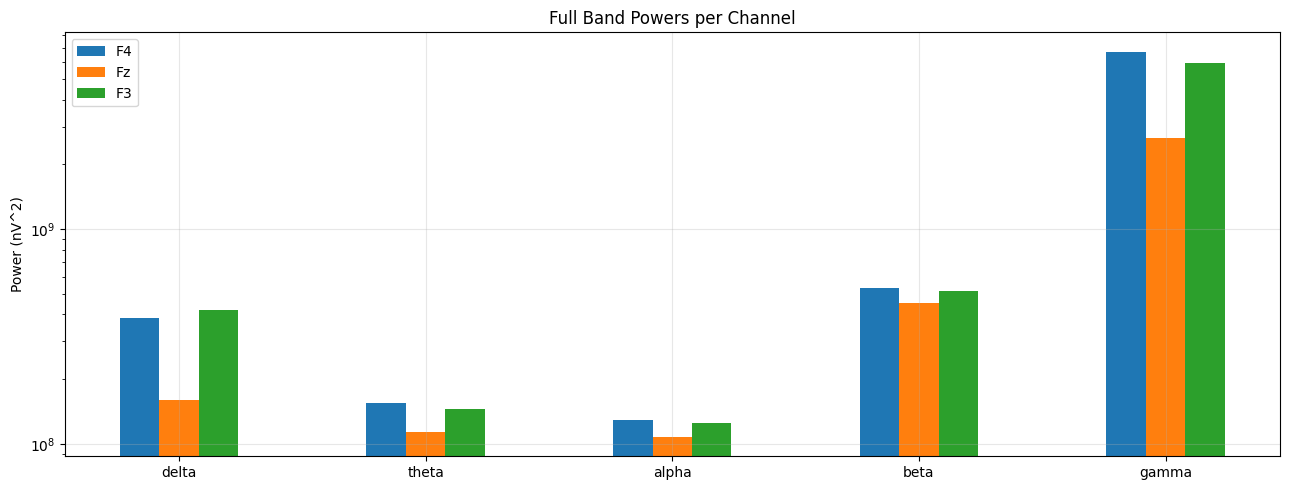

In [7]:
from lsl_test.eeg_processor import compute_channel_band_powers

# 使用批量函数一次性计算所有通道的五频段功率
channel_labels = [meta.signals[i].label for i in eeg_indices]
channel_band_powers = compute_channel_band_powers(signals, channel_labels, sample_rate=sample_rate)

# 绘制柱状图：每个通道都有完整五频段
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
x = np.arange(len(bands))
width = 0.16

fig, ax = plt.subplots(figsize=(13, 5))
for i, (label, bp) in enumerate(channel_band_powers.items()):
    values = [bp.delta, bp.theta, bp.alpha, bp.beta, bp.gamma]
    ax.bar(x + i * width, values, width, label=label)

ax.set_ylabel('Power (nV^2)')
ax.set_title('Full Band Powers per Channel')
ax.set_xticks(x + width * (len(channel_band_powers) - 1) / 2)
ax.set_xticklabels(bands)
ax.legend()
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 滑动窗口分析

共产生 1077 个窗口结果


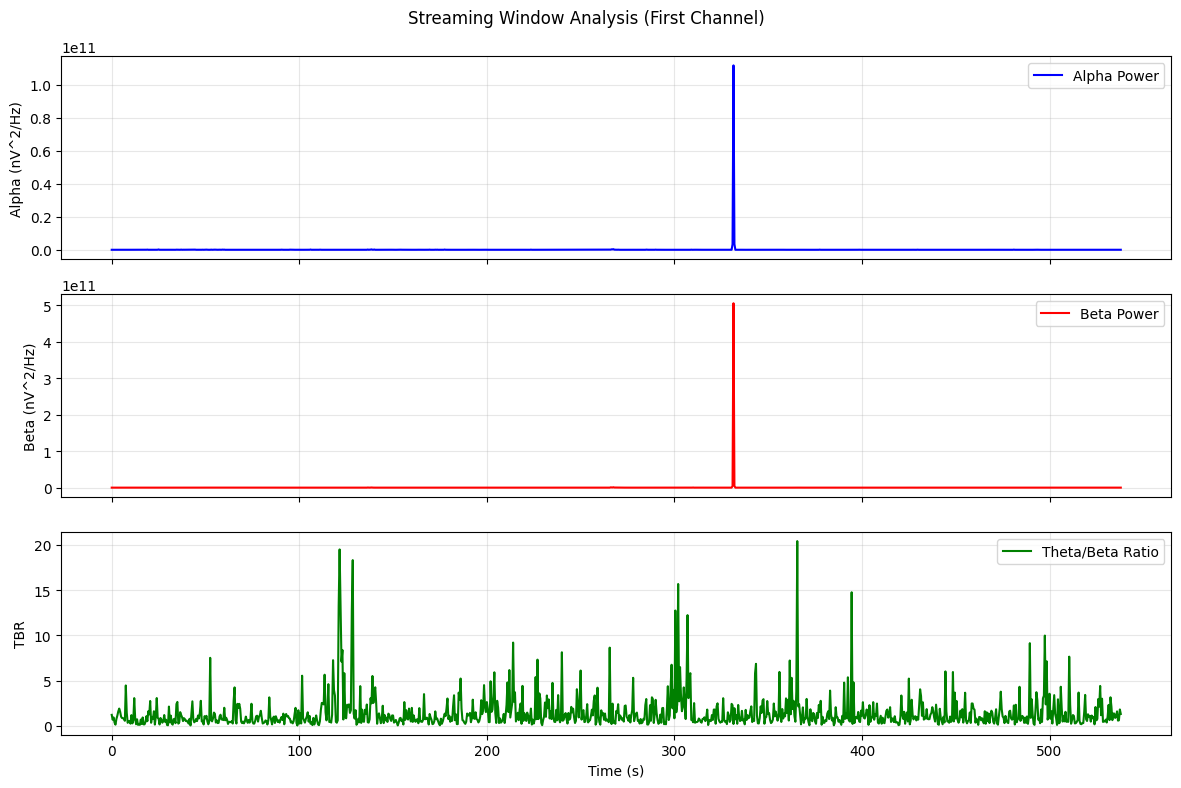

In [8]:
# 演示 Phase 1 的核心组件: StreamingBandPowerExtractor
from lsl_test.eeg_processor import StreamingBandPowerExtractor, DSPConfig

# 对前3个通道进行流式处理，模拟实时数据流接收
n_channels = 3
signals_to_process = signals[:n_channels, :]
extractor = StreamingBandPowerExtractor(sample_rate=sample_rate, n_channels=n_channels)

alpha_powers = []
beta_powers = []
theta_beta_ratios = []

chunk_size = 50  # 模拟每次接收 0.1 秒的数据 (50 samples @ 500Hz)
n_samples = signals_to_process.shape[1]

for i in range(0, n_samples, chunk_size):
    chunk = signals_to_process[:, i:i+chunk_size]
    results = extractor.feed_chunk(chunk)
    
    # 当内部 buffer 达到 window_sec (默认 1s) 并按 hop_sec (默认 0.5s) 滑动时，会返回特征
    for frame_bps in results:
        # frame_bps: Dict[int, BandPowers]
        bp = frame_bps[0]  # 取第0个通道演示
        alpha_powers.append(bp.alpha)
        beta_powers.append(bp.beta)
        tbr = bp.theta / (bp.beta + 1e-9)
        theta_beta_ratios.append(tbr)

print(f"共产生 {len(alpha_powers)} 个窗口结果")

# 绘制时间序列
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
t_windows = np.arange(len(alpha_powers)) * 0.5

axes[0].plot(t_windows, alpha_powers, 'b-', label='Alpha Power')
axes[0].set_ylabel('Alpha (nV^2/Hz)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_windows, beta_powers, 'r-', label='Beta Power')
axes[1].set_ylabel('Beta (nV^2/Hz)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_windows, theta_beta_ratios, 'g-', label='Theta/Beta Ratio')
axes[2].set_ylabel('TBR')
axes[2].set_xlabel('Time (s)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Streaming Window Analysis (First Channel)')
plt.tight_layout()
plt.show()

## 7. 使用 Policy 计算控制意图

`FocusPolicy` 需要 `beta_alpha_theta` 驱动速度、`alpha_asym` 驱动转向。
本 demo 仅使用单通道频段功率，没有 `left_alpha` / `right_alpha`，因此 `alpha_asym` 将恒为 0，
实际实验中需要左右脑区独立 alpha 数据才能产生转向差异。


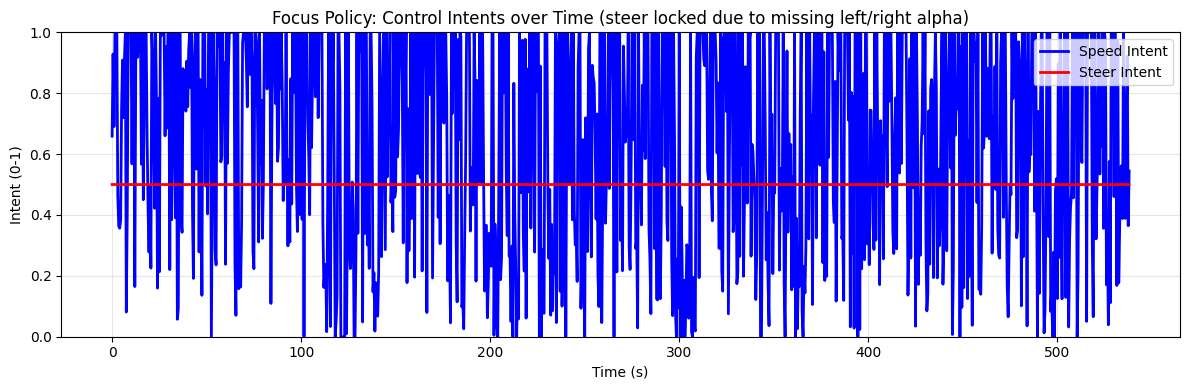

In [9]:
from thymio_control.eeg_control_pipeline import FocusPolicy, enrich_features
from lsl_test.eeg_processor import band_power_to_metrics

# 使用 StreamingBandPowerExtractor 结果计算控制意图
policy = FocusPolicy()
speed_intents = []
steer_intents = []

extractor.reset()
for i in range(0, n_samples, chunk_size):
    chunk = signals_to_process[:, i:i+chunk_size]
    results = extractor.feed_chunk(chunk)
    
    for frame_bps in results:
        bp = frame_bps[0]
        metrics = band_power_to_metrics(bp)
        enriched = enrich_features(metrics)
        intents = policy.compute_intents(enriched)
        speed_intents.append(intents['speed_intent'])
        steer_intents.append(intents['steer_intent'])

# 绘制意图曲线
fig, ax = plt.subplots(figsize=(12, 4))
t_windows = np.arange(len(speed_intents)) * 0.5
ax.plot(t_windows, speed_intents, 'b-', label='Speed Intent', linewidth=2)
ax.plot(t_windows, steer_intents, 'r-', label='Steer Intent', linewidth=2)
ax.set_ylabel('Intent (0-1)')
ax.set_xlabel('Time (s)')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title('Focus Policy: Control Intents over Time (steer locked due to missing left/right alpha)')
plt.tight_layout()
plt.show()


## 8. EDF → LSL 模拟流 (可选，需要 pylsl)

注意：`EdfToLslBridge` 推送的是**原始 EEG 信号**（20 通道 @ 500 Hz），
不是频段功率。因此 `LslAdapter` 的 `channel_map` 应映射为原始通道名称（如 P7=0），
而不是频段名称（如 alpha=0）。


In [10]:
# 先关闭 EDF reader，避免文件被 pyedflib 锁定
if 'reader' in globals():
    reader.close()
    print("EDF reader 己关闭，文件锁释放。")

try:
    import pylsl
    from lsl_test.edf_to_lsl import EdfToLslBridge
    import time

    # 必须用 realtime=True，否则数据在 adapter 连接前就推完了
    sid = "demo_eeg_01"
    bridge = EdfToLslBridge(edf_path, realtime=True, playback_speed=10.0, source_id=sid)
    bridge.start()
    time.sleep(1.0)  # 等待 LSL 注册 + 数据开始流动

    # RawLslAdapter 内部实例化 StreamingBandPowerExtractor 处理原始数据，
    # 返回的 EegFrame 直接包含特征 (metrics)，设备无关！
    from lsl_test.raw_lsl_adapter import RawLslAdapter

    adapter = RawLslAdapter(source_id=sid, timeout=3.0)

    print(f"连接成功！采样率: {adapter.sample_rate}Hz, 通道数: {adapter.n_channels}")

    # 读取帧 — 需要积累 1 秒数据才会产生第一帧
    frames_read = 0
    for i in range(100):
        frame = adapter.read_frame()
        if frame:
            if hasattr(frame, 'metrics'):
                metrics = frame.metrics
                ts = frame.ts
                source = frame.source
            else:
                metrics = frame['metrics']
                ts = frame['ts']
                source = frame['source']
            
            vals = {k: round(v, 2) for k, v in list(metrics.items())[:3]}
            print(f"Frame {frames_read}: source={source}, ts={ts:.2f}, sample_metrics={vals}")
            frames_read += 1
            if frames_read >= 5:
                break
        time.sleep(0.05)

    bridge.stop()
    print("LSL bridge stopped.")

except ImportError as e:
    print(f"缺少依赖: {e}")
    print("pylsl: pip install pylsl")
except Exception as e:
    if 'bridge' in dir():
        bridge.stop()
    print(f"Error: {e}")

EDF reader 己关闭，文件锁释放。


2026-04-26 20:16:05.924 (   0.016s) [            7E71]      netinterfaces.cpp:91    INFO| netif 'lo0' (status: 1, multicast: 32768, broadcast: 0)
2026-04-26 20:16:05.924 (   0.016s) [            7E71]      netinterfaces.cpp:91    INFO| netif 'lo0' (status: 1, multicast: 32768, broadcast: 0)
2026-04-26 20:16:05.924 (   0.016s) [            7E71]      netinterfaces.cpp:102   INFO| 	IPv4 addr: 7f000001
2026-04-26 20:16:05.924 (   0.016s) [            7E71]      netinterfaces.cpp:91    INFO| netif 'lo0' (status: 1, multicast: 32768, broadcast: 0)
2026-04-26 20:16:05.924 (   0.016s) [            7E71]      netinterfaces.cpp:105   INFO| 	IPv6 addr: ::1
2026-04-26 20:16:05.924 (   0.016s) [            7E71]      netinterfaces.cpp:91    INFO| netif 'lo0' (status: 1, multicast: 32768, broadcast: 0)
2026-04-26 20:16:05.924 (   0.016s) [            7E71]      netinterfaces.cpp:105   INFO| 	IPv6 addr: fe80::1%lo0
2026-04-26 20:16:05.924 (   0.016s) [            7E71]      netinterfaces.cpp:91    I

连接成功！采样率: 500Hz, 通道数: 20
Frame 0: source=lsl_raw, ts=1777227367.36, sample_metrics={'alpha': 1605667.7, 'beta': 5910886.96, 'theta': 2887707.96}
Frame 1: source=lsl_raw, ts=1777227367.42, sample_metrics={'alpha': 4957441.8, 'beta': 16768305.47, 'theta': 6026550.41}
Frame 2: source=lsl_raw, ts=1777227367.47, sample_metrics={'alpha': 4506446.37, 'beta': 16231621.4, 'theta': 7109418.07}
Frame 3: source=lsl_raw, ts=1777227367.53, sample_metrics={'alpha': 2295662.28, 'beta': 11400454.85, 'theta': 8833764.39}
Frame 4: source=lsl_raw, ts=1777227367.64, sample_metrics={'alpha': 3497087.02, 'beta': 11214296.4, 'theta': 2638222.77}
LSL bridge stopped.


2026-04-26 20:16:07.647 (   1.739s) [R_Patient01_EE  ]      data_receiver.cpp:344    ERR| Stream transmission broke off (Input stream error.); re-connecting...


## 9. 清理

In [11]:
# 确保 EDF reader 已关闭
if 'reader' in globals():
    try:
        reader.close()
    except Exception:
        pass
print("Done.")


Done.
